# 02 Walk-Forward Validation of the Multivariate Pair Trading Strategy

Evaluation of the MPTS with **rolling-window walk-forward
validation** — every fold re-calibrates the signal thresholds,
mean-reversion speed, expected returns and pair covariances on its own fixed-length
calibration window, then trades the next 12 months out-of-sample:

1. illustrate the threshold grid search on the first calibration window;
2. run the walk-forward loop (a single 70/30 split was used in the original report);
3. per-fold diagnostics: chosen thresholds, trade counts, Sharpe dispersion;
4. stitched out-of-sample equity curve vs. buy-and-hold benchmarks.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from src import backtest, data, hedging, metrics, signals, stat_tests, walk_forward

cfg = yaml.safe_load(open("../configs/bloomberg.yaml", encoding="utf-8"))
ANCHOR = cfg["universe"]["anchor"]
EQUITIES = cfg["universe"]["equities"]
WINDOW = cfg["signals"]["zscore_window"]
WF = cfg["walk_forward"]
RF = cfg["strategy"]["risk_free_rate"]
TC = cfg["strategy"]["transaction_cost"]

In [2]:
prices = data.load_prices("../" + cfg["data"]["path"])
log_prices = data.to_log_prices(prices)

## 1. Threshold calibration: what one fold sees

Grid search over `open ∈ [1.0, 2.5)` and `close ∈ [0.5, 2.0)` (step 0.1,
`close < open` enforced) on the **first calibration window**, maximizing the
average single-spread Sharpe across the basket. The walk-forward loop
repeats this per fold and picks the *median of the top decile* (the plateau)
instead of the argmax cell, reducing per-fold selection bias.

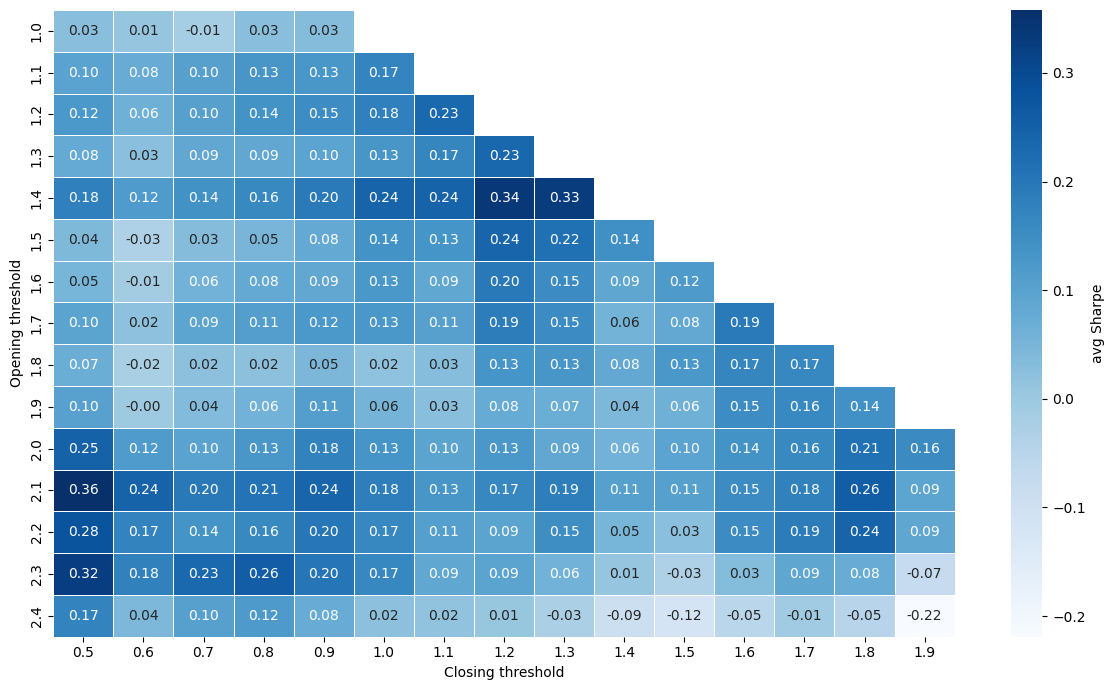

Plateau thresholds for fold 1: open=±2.1, close=±1.0


In [3]:
log_screen = data.screening_window(log_prices, WF["calibration_years"])
grid_results, heatmap = signals.grid_search_thresholds(
    log_screen, EQUITIES, ANCHOR, window=WINDOW, risk_free_rate=RF
)
open_grid = np.round(np.arange(1.0, 2.5, 0.1), 1)
close_grid = np.round(np.arange(0.5, 2.0, 0.1), 1)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heatmap, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=close_grid, yticklabels=open_grid,
            linewidths=0.5, cbar_kws={"label": "avg Sharpe"}, ax=ax)
ax.set_xlabel("Closing threshold")
ax.set_ylabel("Opening threshold")
plt.tight_layout()
plt.show()

plateau_open, plateau_close = walk_forward.calibrate_thresholds(
    log_screen, EQUITIES, ANCHOR, window=WINDOW, risk_free_rate=RF
)
print(f"Plateau thresholds for fold 1: open=±{plateau_open}, close=±{plateau_close}")

## 2. Run the walk-forward validation

In [4]:
CANDIDATES = [c for c in log_prices.columns
              if c not in set(cfg["universe"]["exclude"]) | {ANCHOR}]
BASE_LAMBDA = cfg["strategy"]["risk_aversion"]
SWEEP = sorted({BASE_LAMBDA, *cfg["strategy"].get("risk_aversion_sweep", [])})

results = {}
for lam in SWEEP:
    results[lam] = walk_forward.run_walk_forward(
        log_prices, EQUITIES, ANCHOR, [ANCHOR, cfg["universe"]["sector_proxy"]],
        calibration_years=WF["calibration_years"],
        test_months=WF["test_months"],
        embargo_days=WF["embargo_days"],
        window=WINDOW,
        risk_aversion=lam,
        transaction_cost=TC,
        risk_free_rate=RF,
        rolling_beta_window=cfg["strategy"]["rolling_beta_window"],
        solver=cfg["strategy"]["solver"],
        candidates=CANDIDATES, # per-fold basket re-selection
        n_pairs=cfg["universe"]["n_pairs"],
        max_gross_exposure=cfg["strategy"].get("max_gross_exposure", 1.0),
        verbose=(lam == BASE_LAMBDA),
    )

base = results[BASE_LAMBDA]
base.folds.round(3)

Restricted license - for non-production use only - expires 2027-11-29
fold 1: calibrate 2016-02-12 -> 2019-12-24 | test 2020-01-23 -> 2020-12-10 | basket [SJM,FARM] | thresholds +/-1.6/+/-0.8 | 26 trades | Sharpe 0.739
fold 2: calibrate 2017-01-31 -> 2020-12-10 | test 2021-01-11 -> 2021-11-29 | basket [JVA,FARM] | thresholds +/-1.7/+/-0.8 | 25 trades | Sharpe 0.168
fold 3: calibrate 2018-01-18 -> 2021-11-29 | test 2021-12-29 -> 2022-11-16 | basket [SJM,MCD,NSGRY,KO] | thresholds +/-2.2/+/-0.8 | 29 trades | Sharpe -2.225
fold 4: calibrate 2019-01-07 -> 2022-11-16 | test 2022-12-16 -> 2023-11-03 | basket [MDLZ,MCD,KO,SJM] | thresholds +/-2.4/+/-1.1 | 23 trades | Sharpe -1.855
fold 5: calibrate 2019-12-25 -> 2023-11-03 | test 2023-12-05 -> 2024-10-22 | basket [KO,NESN,NSGRY,MCD] | thresholds +/-2.3/+/-1.0 | 14 trades | Sharpe -0.918
fold 6: calibrate 2020-12-11 -> 2024-10-22 | test 2024-11-21 -> 2025-10-09 | basket [KO,MCD,NESN,MDLZ] | thresholds +/-1.7/+/-0.7 | 48 trades | Sharpe 1.578
f

,fold,cal_start,test_start,test_end,basket,open_th,close_th,n_trades,sharpe,total_return
0,1,2016-02-12,2020-01-23,2020-12-10,"SJM,FARM",1.6,0.8,26,0.739,0.246
1,2,2017-01-31,2021-01-11,2021-11-29,"JVA,FARM",1.7,0.8,25,0.168,0.031
2,3,2018-01-18,2021-12-29,2022-11-16,"SJM,MCD,NSGRY,KO",2.2,0.8,29,-2.225,-0.211
3,4,2019-01-07,2022-12-16,2023-11-03,"MDLZ,MCD,KO,SJM",2.4,1.1,23,-1.855,-0.030
4,5,2019-12-25,2023-12-05,2024-10-22,"KO,NESN,NSGRY,MCD",2.3,1.0,14,-0.918,0.015
5,6,2020-12-11,2024-11-21,2025-10-09,"KO,MCD,NESN,MDLZ",1.7,0.7,48,1.578,0.290
6,7,2021-11-30,2025-11-10,2026-02-12,"JVA,MCD",1.3,1.0,9,-2.933,-0.098


The per-fold table is the honest headline: with ~6 annual folds, report the
**median fold Sharpe and its range**, not a single number. Note how the
chosen thresholds move across folds — threshold economics are
regime-dependent, which the single-split design could never reveal.

## 3. Aggressiveness: the $\lambda$ sweep and gross exposure

$\lambda$ is the risk-aversion coefficient of the bi-objective optimizer and
acts as the **position-size dial** (report, Section 4.2): a lower $\lambda$
weakens the variance penalty and sizes positions up to the gross-exposure
budget; it does not change entry/exit timing, which is threshold-driven.
`max_gross_exposure` extends the paper's no-leverage constraint to a levered
book (2x gross here — conservative by market-neutral industry standards,
where 2–4x is typical); the borrowed portion is financed daily at the
risk-free rate, so leverage is not free.

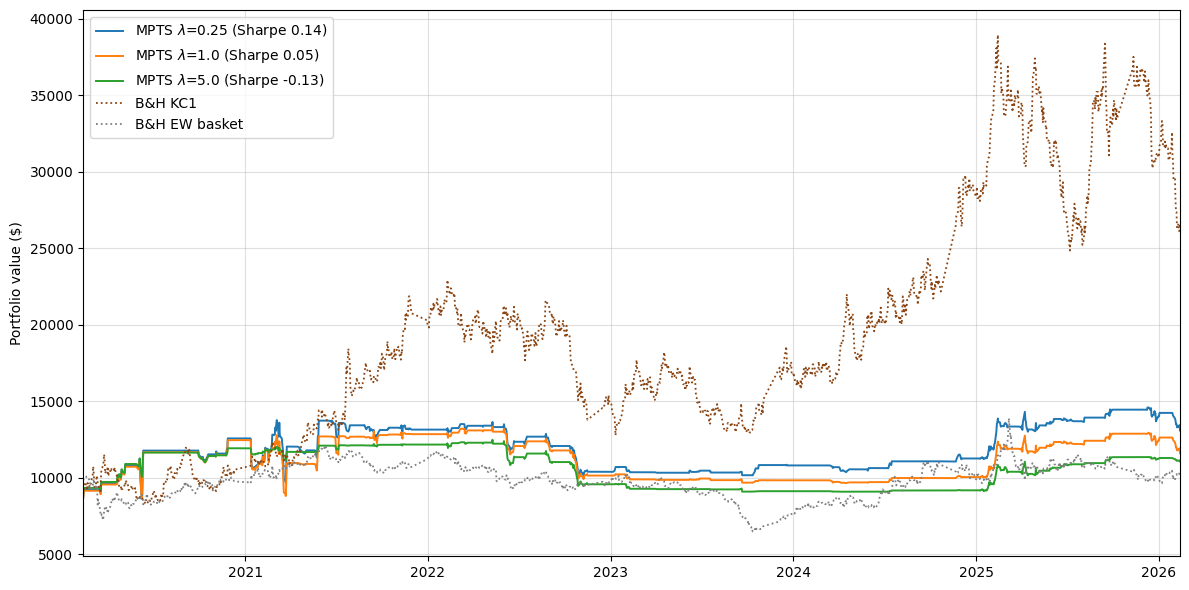

,MPTS lambda=0.25,MPTS lambda=1.0,MPTS lambda=5.0,B&H KC1,B&H EW basket
sharpe,0.1451,0.0511,-0.1297,0.5326,-0.0284
annualized_return,0.0478,0.0262,0.0177,0.1849,0.0066
total_return,0.3090,0.1609,0.1065,1.6612,0.0386
annualized_volatility,0.2253,0.2235,0.1159,0.3770,0.2284
max_drawdown,-0.2975,-0.3111,-0.2724,-0.4430,-0.4605


In [11]:
CAPITAL = cfg["backtest"]["initial_capital"]
log_oos = log_prices.loc[base.pnl.index]
kc1_value = backtest.buy_and_hold_benchmark(log_oos, [ANCHOR], CAPITAL, TC)
ew_value = backtest.buy_and_hold_benchmark(log_oos, EQUITIES, CAPITAL, TC)

fig, ax = plt.subplots(figsize=(12, 6))
for lam, res in results.items():
    ax.plot(res.portfolio_value(CAPITAL), lw=1.4,
            label=f"MPTS $\lambda$={lam} (Sharpe {res.sharpe:.2f})")
ax.plot(kc1_value, ls=":", color="saddlebrown", lw=1.3, label=f"B&H {ANCHOR}")
ax.plot(ew_value, ls=":", color="grey", lw=1.3, label="B&H EW basket")
ax.set_ylabel("Portfolio value ($)"); ax.legend(); ax.grid(alpha=0.4)
ax.set_xlim([pd.to_datetime('2020-02-12'), pd.to_datetime('2026-02-12')])
plt.tight_layout(); plt.show()

report = pd.DataFrame(
    {f"MPTS lambda={lam}": metrics.portfolio_metrics(res.portfolio_value(CAPITAL), RF)
     for lam, res in results.items()}
)
report[f"B&H {ANCHOR}"] = pd.Series(metrics.portfolio_metrics(kc1_value, RF))
report["B&H EW basket"] = pd.Series(metrics.portfolio_metrics(ew_value, RF))
report.round(4)

## 4. Trade-level statistics and fold dispersion

In [12]:
display(pd.Series(metrics.trade_metrics(base.trades)).round(4).to_frame("value"))
print(f"Fold Sharpe: median {base.folds['sharpe'].median():.3f}, "
      f"range [{base.folds['sharpe'].min():.3f}, {base.folds['sharpe'].max():.3f}]")

,value
n_trades,174.0000
pct_winning,0.5747
pct_losing,0.4253
pct_long_win,0.5714
pct_short_win,0.5789
win_loss_ratio,0.9766
average_win,0.0245
average_loss,-0.0251
largest_win,0.1893
largest_loss,-0.1465


Fold Sharpe: median -0.918, range [-2.933, 1.578]
